In [78]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [79]:
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 2)
    & (tourney_df['Illinois'] > 2)
    ]
tourney_df.Probability = tourney_df.Probability / tourney_df.Probability.sum()

In [80]:
win_df = tourney_df[['Winner', 'Probability']].groupby(['Winner']).sum()
win_df.sort_values(by='Probability', ascending=False, inplace=True)

win_df_nice = win_df.copy()
win_df_nice = win_df_nice.loc[win_df_nice['Probability'] > 0.05]
other = 1.0 - win_df_nice['Probability'].sum()
if other > 0.0001:
    win_df_nice.loc['Other'] = [other]

second_df = tourney_df[['Second', 'Probability']].groupby(['Second']).sum()
second_df.sort_values(by='Probability', ascending=False, inplace=True)

second_df_nice = second_df.copy()
second_df_nice = second_df_nice.loc[second_df_nice['Probability'] > 0.05]
other = 1.0 - second_df_nice['Probability'].sum()
if other > 0.0001:
    second_df_nice.loc['Other'] = [other]

third_df = tourney_df[['Third', 'Probability']].groupby(['Third']).sum()
third_df.sort_values(by='Probability', ascending=False, inplace=True)

third_df_nice = third_df.copy()
third_df_nice = third_df_nice.loc[third_df_nice['Probability'] > 0.05]
other = 1.0 - third_df_nice['Probability'].sum()
if other > 0.0001:
    third_df_nice.loc['Other'] = [other]


In [81]:
all_labels = set(win_df_nice.index) | set(second_df_nice.index) | set(third_df_nice.index)

In [82]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [83]:
from math import sin, cos, sqrt, gcd, pi

seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

Bobby Ingram
Dan Wros
George Wright
Justin Calvillo
Keith Schneider
Koy Kubasta
Nathan Sanches
Other
Patrick Commers
Serigne Diaw
Tyler Krause
none


{'Dan Wros': [0.5690355937288492, 0.9633731610262555, 0.6746980264314426],
 'Keith Schneider': [0.5080313597647761,
  0.9023689270621824,
  0.7967064943595888],
 'Serigne Diaw': [0.5080313597647761, 0.796706494359589, 0.9023689270621824],
 'Other': [0.5690355937288492, 0.6746980264314427, 0.9633731610262555],
 'Koy Kubasta': [0.6746980264314426, 0.5690355937288492, 0.9633731610262555],
 'Nathan Sanches': [0.7967064943595888,
  0.5080313597647761,
  0.9023689270621824],
 'none': [0.9023689270621824, 0.5080313597647761, 0.796706494359589],
 'Tyler Krause': [0.9633731610262555, 0.569035593728849, 0.6746980264314428],
 'Bobby Ingram': [0.9633731610262556, 0.6746980264314426, 0.5690355937288493],
 'Patrick Commers': [0.9023689270621824,
  0.7967064943595888,
  0.5080313597647761],
 'George Wright': [0.7967064943595891, 0.9023689270621823, 0.508031359764776],
 'Justin Calvillo': [0.6746980264314428,
  0.9633731610262555,
  0.569035593728849]}

In [84]:
dfs = [win_df_nice, second_df_nice, third_df_nice]
disp_titles = ['1st Place', '2nd Place', '3rd Place']

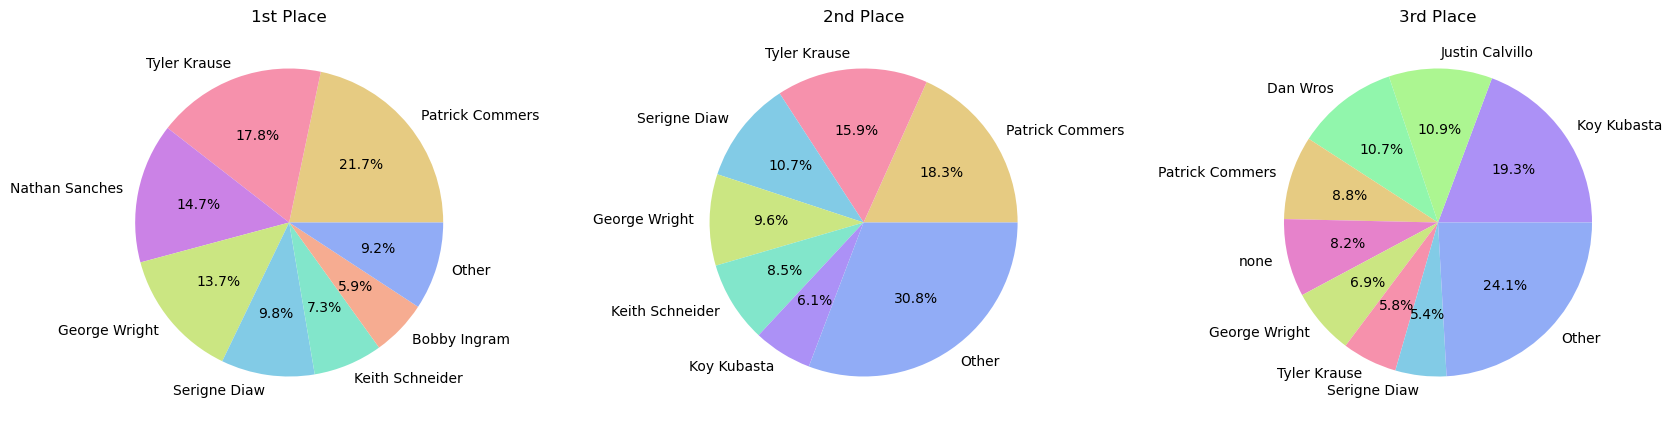

In [85]:
fig, axs = plt.subplots(1, 3, figsize = [21, 5])

for ax, title, df in zip(axs.flatten(), disp_titles, dfs):
    labels=df.index
    colors = [color_dict[label] for label in labels]
    labels = [_ for _ in labels]
    ax.pie(df['Probability'], 
           labels=labels,
           autopct='%1.1f%%',
           normalize=True,
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')

plt.savefig('plots/win_place_show.png', dpi=300, bbox_inches='tight')

In [86]:
pot = 425.0
prizes = {
    1: 0.6 * pot,
    2: 0.3 * pot,
    3: .01 * pot
}

ev_dict = {}

for winner in win_df.index:
    winners = winner.split(', ')
    prob = win_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[1]
    elif nwinners == 2:
        total_prize = prizes[1] + prizes[2]
    else:
        total_prize = prizes[1] + prizes[2] + prizes[3]
    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in second_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = second_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[2]
    else:
        total_prize = prizes[2] + prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in third_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = third_df.loc[winner, 'Probability']
    nwinners = len(winners)
    total_prize = prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 
# ev_dict

ev_df = pd.DataFrame.from_dict(data=ev_dict, orient='index', columns=['EV (USD)'])
ev_df.sort_values(by='EV (USD)', ascending=False, inplace=True)
ev_df['EV (GBP)'] = ev_df['EV (USD)']  * 0.75
ev_df
    

,EV (USD),EV (GBP)
Patrick Commers,79.029028,59.271771
Tyler Krause,71.144900,53.358675
George Wright,49.537140,37.152855
Nathan Sanches,39.950494,29.962871
Serigne Diaw,39.290867,29.468150
Keith Schneider,35.558287,26.668715
Bobby Ingram,17.685868,13.264401
Koy Kubasta,16.396854,12.297641
Mark Hurst,11.816485,8.862364
Dan Wros,7.640109,5.730082


In [87]:
from IPython.display import display

display(ev_df.style.format({
    'EV (USD)': '${:,.2f}',
    'EV (GBP)': '£{:,.2f}' # Example for a different currency without decimals
}))



,EV (USD),EV (GBP)
Patrick Commers,$79.03,£59.27
Tyler Krause,$71.14,£53.36
George Wright,$49.54,£37.15
Nathan Sanches,$39.95,£29.96
Serigne Diaw,$39.29,£29.47
Keith Schneider,$35.56,£26.67
Bobby Ingram,$17.69,£13.26
Koy Kubasta,$16.40,£12.30
Mark Hurst,$11.82,£8.86
Dan Wros,$7.64,£5.73


In [88]:
print(ev_df)

                  EV (USD)   EV (GBP)
Patrick Commers  79.029028  59.271771
Tyler Krause     71.144900  53.358675
George Wright    49.537140  37.152855
Nathan Sanches   39.950494  29.962871
Serigne Diaw     39.290867  29.468150
Keith Schneider  35.558287  26.668715
Bobby Ingram     17.685868  13.264401
Koy Kubasta      16.396854  12.297641
Mark Hurst       11.816485   8.862364
Dan Wros          7.640109   5.730082
Danny Ryan        5.592647   4.194485
Justin Calvillo   4.880944   3.660708
Ian Thorpe        4.461027   3.345770
Justin Pajela     3.765352   2.824014


In [89]:
pd.set_option('display.max_colwidth', 70)
print(win_df)

                                                       Probability
Winner                                                            
Patrick Commers                                           0.217048
Tyler Krause                                              0.177796
Nathan Sanches                                            0.146903
George Wright                                             0.136709
Serigne Diaw                                              0.098102
Keith Schneider                                           0.072617
Bobby Ingram                                              0.058627
Koy Kubasta                                               0.028993
Mark Hurst                                                0.014401
Keith Schneider, Tyler Krause                             0.013655
Danny Ryan, Mark Hurst                                    0.007300
Dan Wros                                                  0.006722
Danny Ryan, Keith Schneider, Mark Hurst                   0.00

In [90]:
pd.set_option('display.max_colwidth', 70)
print(second_df)

                                                                      Probability
Second                                                                           
Patrick Commers                                                          0.182809
Tyler Krause                                                             0.158993
Serigne Diaw                                                             0.107490
George Wright                                                            0.095915
Keith Schneider                                                          0.085475
Koy Kubasta                                                              0.061498
Dan Wros                                                                 0.042914
none                                                                     0.035337
Justin Calvillo                                                          0.034662
Ian Thorpe                                                               0.027224
Justin Pajela   

In [91]:
pd.set_option('display.max_colwidth', 70)
print(third_df)

                                                                      Probability
Third                                                                            
Koy Kubasta                                                              0.193034
Justin Calvillo                                                          0.108586
Dan Wros                                                                 0.106930
Patrick Commers                                                          0.087905
none                                                                     0.081673
George Wright                                                            0.069440
Tyler Krause                                                             0.057760
Serigne Diaw                                                             0.053535
Keith Schneider                                                          0.037532
Justin Pajela                                                            0.037094
Ian Thorpe      